In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [55]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

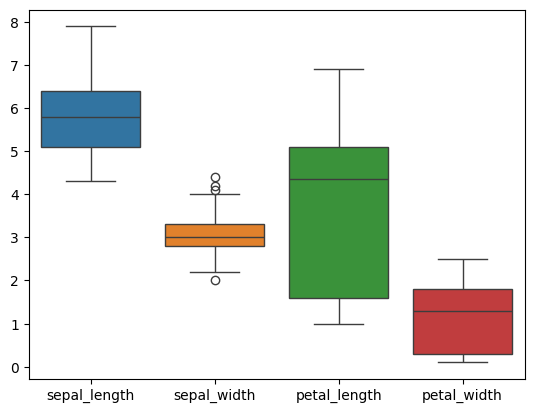

In [57]:
sns.boxplot(data)

In [58]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [59]:
X = data.drop("species", axis=1)
y = data['species']

In [14]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [61]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [65]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [66]:
from sklearn.preprocessing import MinMaxScaler

In [67]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [68]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [69]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [70]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequencial API

In [71]:
from keras.models import Sequential
from keras.layers import Dense, Input

In [74]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9714 - loss: 0.2458 - val_accuracy: 0.9667 - val_loss: 0.2315
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9856 - loss: 0.2369 - val_accuracy: 0.9667 - val_loss: 0.2299
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9760 - loss: 0.2313 - val_accuracy: 0.9667 - val_loss: 0.2259
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9731 - loss: 0.2456 - val_accuracy: 0.9667 - val_loss: 0.2232
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9561 - loss: 0.2326 - val_accuracy: 0.9667 - val_loss: 0.2208
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9797 - loss: 0.2042 - val_accuracy: 0.9667 - val_loss: 0.2176
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9635 - loss: 0.2396 - val_accuracy: 0.9667 - val_loss: 0.2153
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9673 - loss: 0.2167 - val_accuracy: 0.9667 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9610 - loss: 0.1309 - val_accuracy: 0.9667 - val_loss: 0.1301
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9729 - loss: 0.1222 - val_accuracy: 0.9667 - val_loss: 0.1288
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9758 - loss: 0.1234 - val_accuracy: 0.9667 - val_loss: 0.1275
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9702 - loss: 0.1323 - val_accuracy: 0.9667 - val_loss: 0.1266
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9583 - loss: 0.1400 - val_accuracy: 0.9667 - val_loss: 0.1264
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9511 - loss: 0.1366 - val_accuracy: 0.9667 - val_loss: 0.1252
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9636 - loss: 0.1320 - val_accuracy: 0.9667 - val_loss: 0.1235
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9607 - loss: 0.1176 - val_accuracy: 0.9667 - v

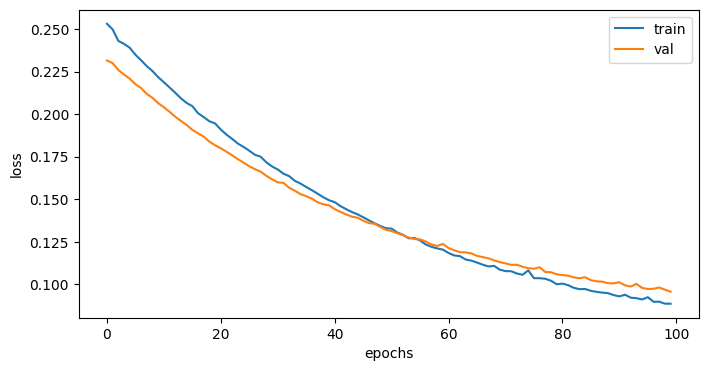

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,5.147107e-07,9.674742e-01,0.032525
18,True,False,False,9.999779e-01,3.422379e-08,0.000022
118,False,False,True,4.676757e-15,2.416727e-04,0.999758
78,False,True,False,1.826132e-07,8.636261e-01,0.136374
76,False,True,False,5.655954e-08,8.712853e-01,0.128715
31,True,False,False,9.998925e-01,4.851959e-07,0.000107
64,False,True,False,3.173011e-06,9.623896e-01,0.037607
141,False,False,True,1.220859e-11,1.541510e-02,0.984585
68,False,True,False,3.858666e-08,2.698655e-01,0.730134
82,False,True,False,2.311247e-06,9.640253e-01,0.035972


In [82]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [81]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [80]:
pd.DataFrame(pred)

,0,1,2
0,2.431699e-03,0.672625,0.324943
1,9.952604e-01,0.000053,0.004686
2,8.007284e-08,0.043257,0.956743
3,8.710978e-04,0.553488,0.445641
4,5.269248e-04,0.536479,0.462994
5,9.914006e-01,0.000193,0.008406
6,6.662285e-03,0.679570,0.313768
7,4.083276e-06,0.137870,0.862126
8,1.597027e-04,0.325342,0.674498
9,5.069907e-03,0.680592,0.314338


Functional API

Subclass API